# Phase 03: Predictive Data Analysis

Objective: Finishing data preprocessing for machine learning and developing a predictive model to identify customers at high risk of churn, enabling targeted retention strategies.

Model Selection: Selected Random Forest for its inherent robustness against outliers and skewed, non-normal distributions present in the dataset. This approach allowed for high-performance modeling without the need for aggressive scaling or feature transformation, thereby preserving the integrity of the original data and preventing information loss.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [18]:
frame = pd.read_csv('../data/intermediate/post-eda.csv', keep_default_na=False)
frame.head(5)

,customer_id,gender,age,married,number_of_dependents,tenure_in_months,number_of_referrals,city,offer,phone_service,...,average_monthly_gb_download,average_monthly_long_distance_charges,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,True,0,9,2,Frazier Park,None,True,...,16.0,42.39,65.6,593.30,0.0,0.0,381.51,Stayed,Still Subscribed,Still Subscribed
1,0004-TLHLJ,Male,50,False,0,4,0,Costa Mesa,Offer E,True,...,30.0,33.65,73.9,280.85,0.0,0.0,134.60,Churned,Competitor,Competitor had better devices
2,0011-IGKFF,Male,78,True,0,13,1,Martinez,Offer D,True,...,4.0,27.82,98.0,1237.85,0.0,0.0,361.66,Churned,Dissatisfaction,Product dissatisfaction
3,0013-EXCHZ,Female,75,True,0,3,3,Camarillo,None,True,...,11.0,7.38,83.9,267.40,0.0,0.0,22.14,Churned,Dissatisfaction,Network reliability
4,0013-MHZWF,Female,23,False,3,9,0,Midpines,Offer E,True,...,73.0,16.77,69.4,571.45,0.0,0.0,150.93,Stayed,Still Subscribed,Still Subscribed


Dropping churn category and churn reason columns to avoid data leak. Additionally, removing ids to avoid overfit:

In [19]:
customer_ids = frame['customer_id']

frame = frame.drop(columns=['customer_id', 'churn_category', 'churn_reason'])

In [20]:
# check if there is any missing values in any column
frame.columns[frame.isna().sum() > 0]

Index([], dtype='str')

Investigating columns to encode:

In [21]:
# check nonnumeric or non-boolean columns
frame.select_dtypes(include='str').info()

<class 'pandas.DataFrame'>
RangeIndex: 6924 entries, 0 to 6923
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gender           6924 non-null   str  
 1   city             6924 non-null   str  
 2   offer            6924 non-null   str  
 3   internet_type    6924 non-null   str  
 4   contract         6924 non-null   str  
 5   payment_method   6924 non-null   str  
 6   customer_status  6924 non-null   str  
dtypes: str(7)
memory usage: 378.8 KB


In [22]:
frame.select_dtypes(include='str').nunique()

gender                2
city               1107
offer                 6
internet_type         4
contract              3
payment_method        3
customer_status       3
dtype: int64

Encoding decisions:
- gender -> Turning into binary using one-hot encoding
- city -> Target encoding due to the amount of unique values
- offer, internet type, payment method -> One-hot encoding (turning into columns) due to having a couple of unique values
- contract -> Contract types can be sorted according to their length which means ordinal encoding

Assigning binary values to customer status (churned -> 1 and not-churned -> 0):

In [23]:
frame.loc[(frame['customer_status'] != 'Churned'), 'customer_status'] = 'Not Churned'
mapping = {'Churned': 1, 'Not Churned': 0}
frame['customer_status'] = frame['customer_status'].map(mapping)

Train/test split (20%):

In [24]:
y = frame['customer_status']
X = frame.drop(columns=['customer_status'])

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Building the pipeline with encoders, feature selection and the model:

In [25]:
bin_columns = ['gender']
ohe_columns = ['internet_type', 'payment_method', 'offer']
ole_columns = ['contract']
te_columns  = ['city']

bin_pipe = Pipeline([
    ("binary_ohe", OneHotEncoder(drop='if_binary', handle_unknown="ignore"))
])

ohe_pipe = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ole_pipe = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[[
        "Month-to-Month",
        "One Year",
        "Two Year"
    ]]))
])

te_pipe = Pipeline([
    ("target", TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("bin", bin_pipe, bin_columns),
        ("ohe", ohe_pipe, ohe_columns),
        ("ole", ole_pipe, ole_columns),
        ("te", te_pipe, te_columns)
    ],
    remainder="passthrough"
)

selector_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", SelectFromModel(estimator=selector_rf, threshold="mean")),
    ("classifier", RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

Initializing the randomized search algorithm to detect near-optimal hyperparameter values without using too much computational power:

In [26]:
param_distributions = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [2, 4, 8],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True],
    'classifier__min_impurity_decrease': [0.0, 0.0001, 0.0005]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

Model training:

In [27]:
random_search.fit(X_train, y_train)

print("\nBEST PARAMETERS")

for (key, val) in random_search.best_params_.items():
    key.replace('classifier__', '')
    print(f"{key}: {val}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

BEST PARAMETERS
classifier__n_estimators: 300
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__min_impurity_decrease: 0.0001
classifier__max_features: sqrt
classifier__max_depth: 15
classifier__bootstrap: True


Model testing and evaluation:


REPORT
                 precision    recall  f1-score   support

Not Churned (0)       0.90      0.87      0.88      1017
    Churned (1)       0.67      0.73      0.70       368

       accuracy                           0.83      1385
      macro avg       0.78      0.80      0.79      1385
   weighted avg       0.84      0.83      0.83      1385


ROC-AUC SCORE
Score: 0.894

CONFUSION MATRIX


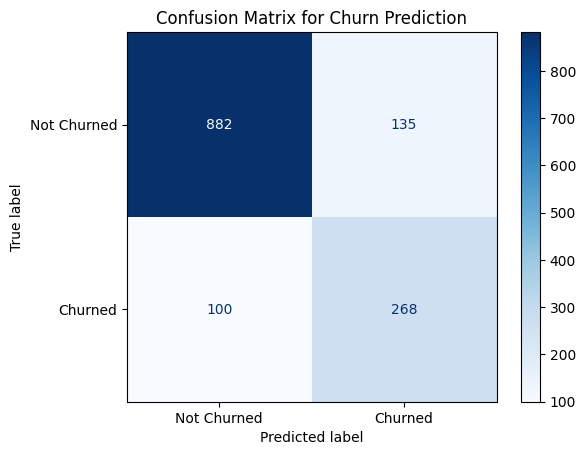

In [28]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_probabilities = best_model.predict_proba(X_test)[:, 1]

print("\nREPORT")
print(classification_report(y_test, y_pred, target_names=['Not Churned (0)', 'Churned (1)']))

print("\nROC-AUC SCORE")
print(f"Score: {round(roc_auc_score(y_test, y_pred_probabilities), 3)}")

print("\nCONFUSION MATRIX")
matrix = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['Not Churned', 'Churned'])

cmd.plot(cmap='Blues')
plt.title('Confusion Matrix for Churn Prediction')
plt.savefig('../data/results/cm.png', bbox_inches='tight', dpi=300)
plt.show()

Saving results:

In [29]:
# metrics
report = classification_report(y_test, y_pred, target_names=['Not Churned (0)', 'Churned (1)'], output_dict=True)

results = pd.DataFrame(report)
results = results.apply(lambda x: round(x, 2))
results.loc['support'] = results.loc['support'].astype(int)
results = results.reset_index().rename(columns={'index': 'metrics'})

results.to_csv('../data/results/results.csv', index=False)

# churn probabilities
probabilities = pd.DataFrame()
probabilities['customer_id'] = id_test
probabilities['probability'] = y_pred_probabilities
probabilities['monthly_charge'] = X_test['monthly_charge'].values
probabilities.to_csv('../data/intermediate/probabilities.csv', index=False)

# parameters
parameters = pd.Series(random_search.best_params_).reset_index()
parameters.columns = ['parameter', 'value']
parameters.to_csv('../data/results/best_parameters.csv', index=False)

While the ROC-AUC indicates moderate overall performance, precision and F1 scores for churn detection remain low despite extensive hyperparameter tuning and feature selection.

This suggests the Random Forest model has reached its performance ceiling on this dataset, and a more powerful architecture such as XGBoost or LightGBM may yield further gains. That said, since perfect classification was not the objective, this solution remains highly actionable: recall improved from 0.72 to 0.78 across iterations, reducing missed churners from 102 to 82.

The model can also be threshold-adjusted to further align precision and recall with specific business goals and budget constraints.